In [11]:
!pip install kaggle

In [12]:
from google.colab import files
files.upload()


Saving kaggle (3).json to kaggle (3) (2).json


{'kaggle (3) (2).json': b'{"username":"oumaimakourchte","key":"e2984afdd09c9dd69cc457e6f9e3af80"}'}

In [17]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [18]:
!kaggle datasets download -d clmentbisaillon/fake-and-real-news-dataset

Dataset URL: https://www.kaggle.com/datasets/clmentbisaillon/fake-and-real-news-dataset
License(s): CC-BY-NC-SA-4.0
100% 41.0M/41.0M [00:01<00:00, 23.5MB/s]



In [19]:
!unzip fake-and-real-news-dataset.zip

Archive:  fake-and-real-news-dataset.zip
  inflating: Fake.csv                
  inflating: True.csv                


In [24]:
import pandas as pd
import numpy as np
import re
import pickle

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report


In [20]:
import os
os.listdir()


['.config',
 'True.csv',
 'kaggle.json',
 'kaggle (3) (2).json',
 'kaggle (3) (1).json',
 'fake-and-real-news-dataset.zip',
 'Fake.csv',
 'sample_data']

In [25]:
import pandas as pd
fake = pd.read_csv("Fake.csv")
true = pd.read_csv("True.csv")
fake["label"] = 0
true["label"] = 1
df = pd.concat([fake, true], axis=0)
df = df.sample(frac=1).reset_index(drop=True)
print(df.shape)
df.head()

(44898, 5)


,title,text,subject,date,label
0,"WAR ON WORDS: Facebook Censorship Widens, Webs...",21st Century Wire says The US media s neoMcCar...,Middle-east,"December 3, 2016",0
1,U.N. environment chief concerned at climate sc...,JAKARTA (Reuters) - Some elite U.S. politician...,politicsNews,"December 14, 2016",1
2,Trump acknowledges he is under investigation i...,WASHINGTON (Reuters) - President Donald Trump ...,politicsNews,"June 16, 2017",1
3,"Amid hacking row, pressure builds on Trump to ...",WASHINGTON (Reuters) - President-elect Donald ...,politicsNews,"January 9, 2017",1
4,GOP Pundit Compared Trump’s Healthcare Disast...,Being a pro-Trump pundit must be a tough racke...,News,"April 13, 2017",0


In [27]:
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"http\S+", "", text)
    text = re.sub(r"[^a-zA-Z ]", "", text)
    return text

In [28]:
df["content"] = df["title"] + " " + df["text"]
df["content"] = df["content"].apply(clean_text)

In [29]:
X = df["content"]
y = df["label"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [30]:
vectorizer = TfidfVectorizer(
    max_features=10000,
    ngram_range=(1,2)
)

X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)


In [33]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC

models = {
    "Logistic": LogisticRegression(max_iter=200),
    "Naive Bayes": MultinomialNB(),
    "SVM": LinearSVC()
}

In [34]:
for name, m in models.items():
    m.fit(X_train_vec, y_train)
    pred = m.predict(X_test_vec)
    acc = accuracy_score(y_test, pred)
    print(f"{name} Accuracy: {acc}")


Logistic Accuracy: 0.9919821826280624
Naive Bayes Accuracy: 0.9580178173719376
SVM Accuracy: 0.9973273942093541


In [36]:
b_model = LinearSVC()
b_model.fit(X_train_vec, y_train)
pickle.dump(b_model, open("b_model.pkl", "wb"))


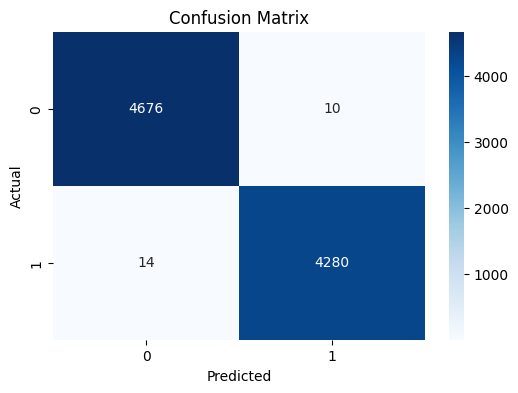

In [39]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

y_pred = b_model.predict(X_test_vec)
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Real")
plt.title("Confusion Matrix")
plt.show()
